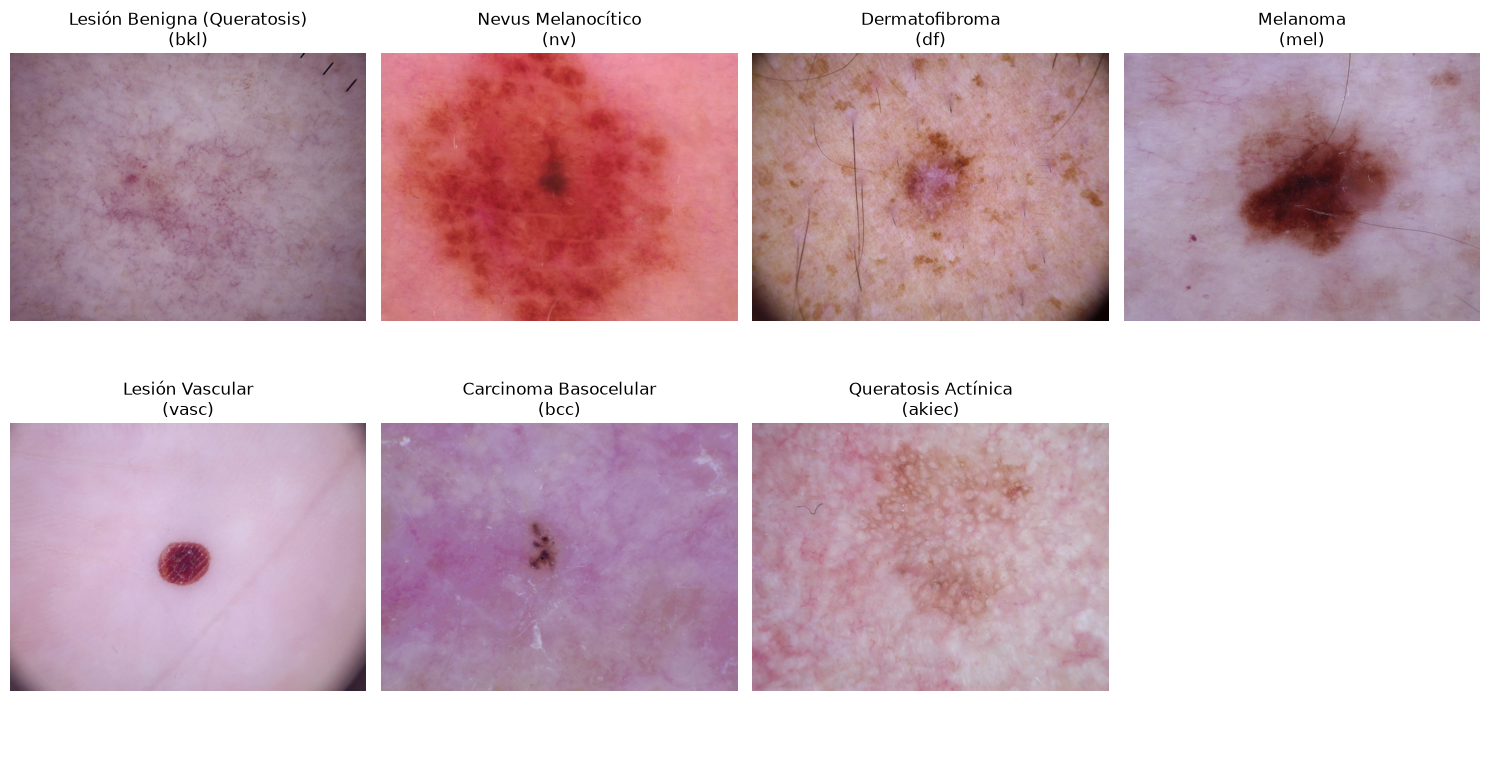

Dataset preparado y guardado en: ../data/HAM10000_metadata_prepared.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

# 1. Definir rutas
metadata_path = '../data/HAM10000_metadata.csv'
images_dir = '../data/images/'

# Cargar el dataframe
df = pd.read_csv(metadata_path)

# 2. Crear una nueva columna con la ruta completa a cada imagen
# Sabemos que las imágenes se llaman como el 'image_id' + '.jpg'
df['image_path'] = df['image_id'].apply(lambda x: os.path.join(images_dir, f"{x}.jpg"))

# Diccionario para que los nombres de los gráficos se entiendan (opcional, pero queda muy pro)
lesion_names = {
    'nv': 'Nevus Melanocítico',
    'mel': 'Melanoma',
    'bkl': 'Lesión Benigna (Queratosis)',
    'bcc': 'Carcinoma Basocelular',
    'akiec': 'Queratosis Actínica',
    'vasc': 'Lesión Vascular',
    'df': 'Dermatofibroma'
}
df['lesion_name'] = df['dx'].map(lesion_names)

# 3. Mostrar un ejemplo aleatorio de cada clase
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

# Iterar sobre cada tipo de lesión único
for i, lesion_type in enumerate(df['dx'].unique()):
    # Seleccionar una imagen aleatoria de este tipo
    sample = df[df['dx'] == lesion_type].sample(1).iloc[0]
    
    # Cargar y mostrar la imagen
    img_path = sample['image_path']
    try:
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"{sample['lesion_name']}\n({lesion_type})")
        axes[i].axis('off')
    except Exception as e:
        axes[i].set_title(f"Error cargando:\n{sample['image_id']}")
        axes[i].axis('off')

# Ocultar el último subplot (tenemos 7 clases pero una cuadrícula de 8)
axes[7].axis('off')
plt.tight_layout()
plt.show()

# 4. Guardar este nuevo DataFrame "preparado" para usarlo en el entrenamiento
output_csv = '../data/HAM10000_metadata_prepared.csv'
df.to_csv(output_csv, index=False)
print(f"Dataset preparado y guardado en: {output_csv}")